In [105]:
import pandas as pd
df = pd.read_csv('NYC_taxi.csv', parse_dates=['pickup_datetime'],
nrows=500000)

In [106]:
df.head()

,key,fare_amount,pickup_datetime,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count
0,2009-06-15 17:26:21.0000001,4.5,2009-06-15 17:26:21+00:00,-73.844311,40.721319,-73.841610,40.712278,1
1,2010-01-05 16:52:16.0000002,16.9,2010-01-05 16:52:16+00:00,-74.016048,40.711303,-73.979268,40.782004,1
2,2011-08-18 00:35:00.00000049,5.7,2011-08-18 00:35:00+00:00,-73.982738,40.761270,-73.991242,40.750562,2
3,2012-04-21 04:30:42.0000001,7.7,2012-04-21 04:30:42+00:00,-73.987130,40.733143,-73.991567,40.758092,1
4,2010-03-09 07:51:00.000000135,5.3,2010-03-09 07:51:00+00:00,-73.968095,40.768008,-73.956655,40.783762,1


In [107]:
nyc_min_longitude = -74.05
nyc_max_longitude = -73.75

nyc_min_latitude = 40.63
nyc_max_latitude = 40.85

df2 = df.copy(deep=True)
for long in ['pickup_longitude', 'dropoff_longitude']:
    df2 = df2[(df2[long] > nyc_min_longitude) & (df2[long] < nyc_max_longitude)]

for lat in ['pickup_latitude', 'dropoff_latitude']:
    df2 = df2[(df2[lat] > nyc_min_latitude) & (df2[lat] < nyc_max_latitude)]

In [108]:
landmarks = {'JFK Airport': (-73.78, 40.643),
'Laguardia Airport': (-73.87, 40.77),
'Midtown': (-73.98, 40.76),
'Lower Manhattan': (-74.00, 40.72),
'Upper Manhattan': (-73.94, 40.82),
'Brooklyn': (-73.95, 40.66)}

In [109]:
import matplotlib.pyplot as plt

def plot_lat_long(df, landmarks, points='Pickup'):
    plt.figure(figsize=(12,12))
    if points == 'pickup':
        plt.plot(list(df.pickup_longitude), list(df.pickup_latitude), '.', markersize=1)
    else:
        plt.plot(list(df.dropoff_longitude), list(df.dropoff_latitude), '.', markersize=1)

    for landmark in landmarks: 
        plt.plot(landmarks[landmark][0], landmarks[landmark][1], '*', markersize=15, alpha=1, color='r')
        plt.annotate(landmark, (landmarks[landmark][0], landmarks[landmark][1]), color='r', fontsize=20)
    plt.title("{} Locations in NYC Illustrated".format(points))
    plt.grid(None)
    plt.xlabel("Latitude")
    plt.ylabel("Longitude")
    plt.show()

    

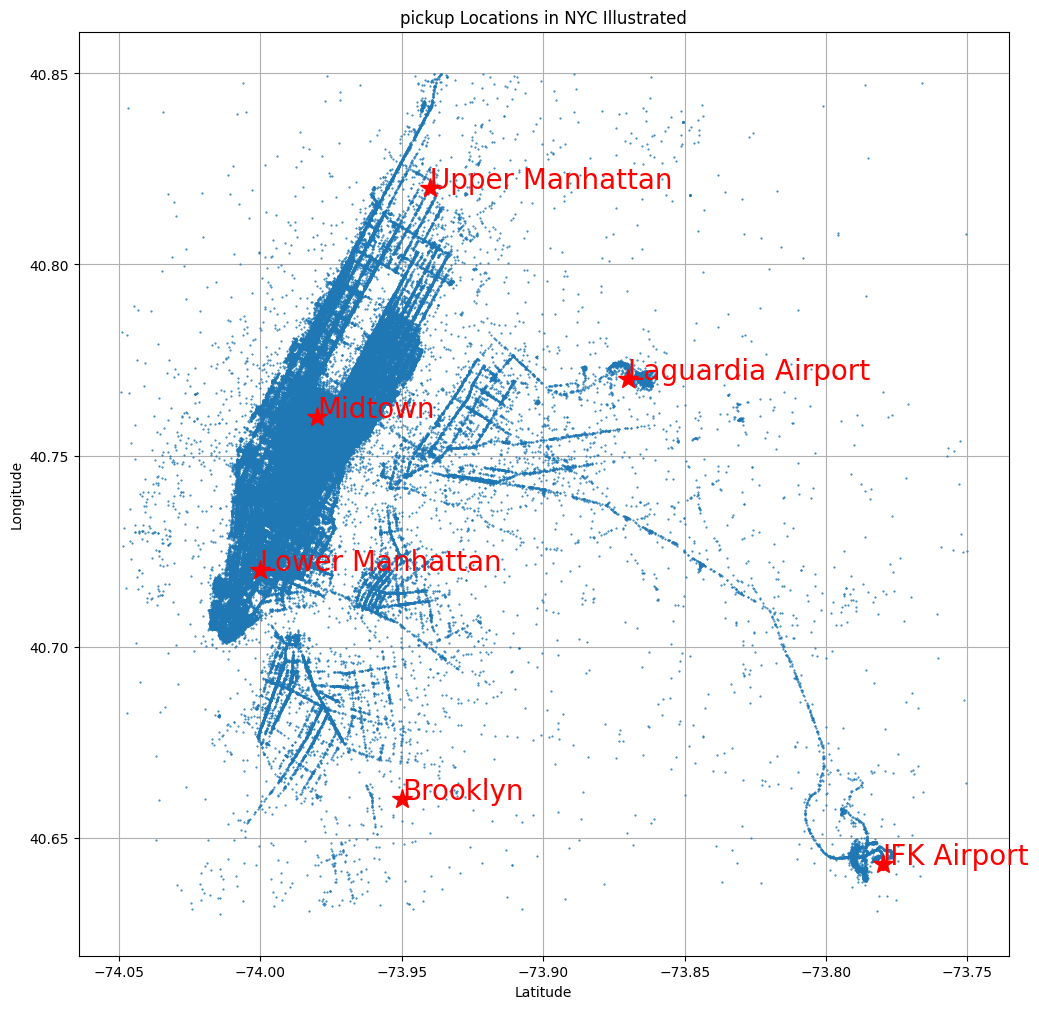

In [110]:
plot_lat_long(df2, landmarks, points='pickup')

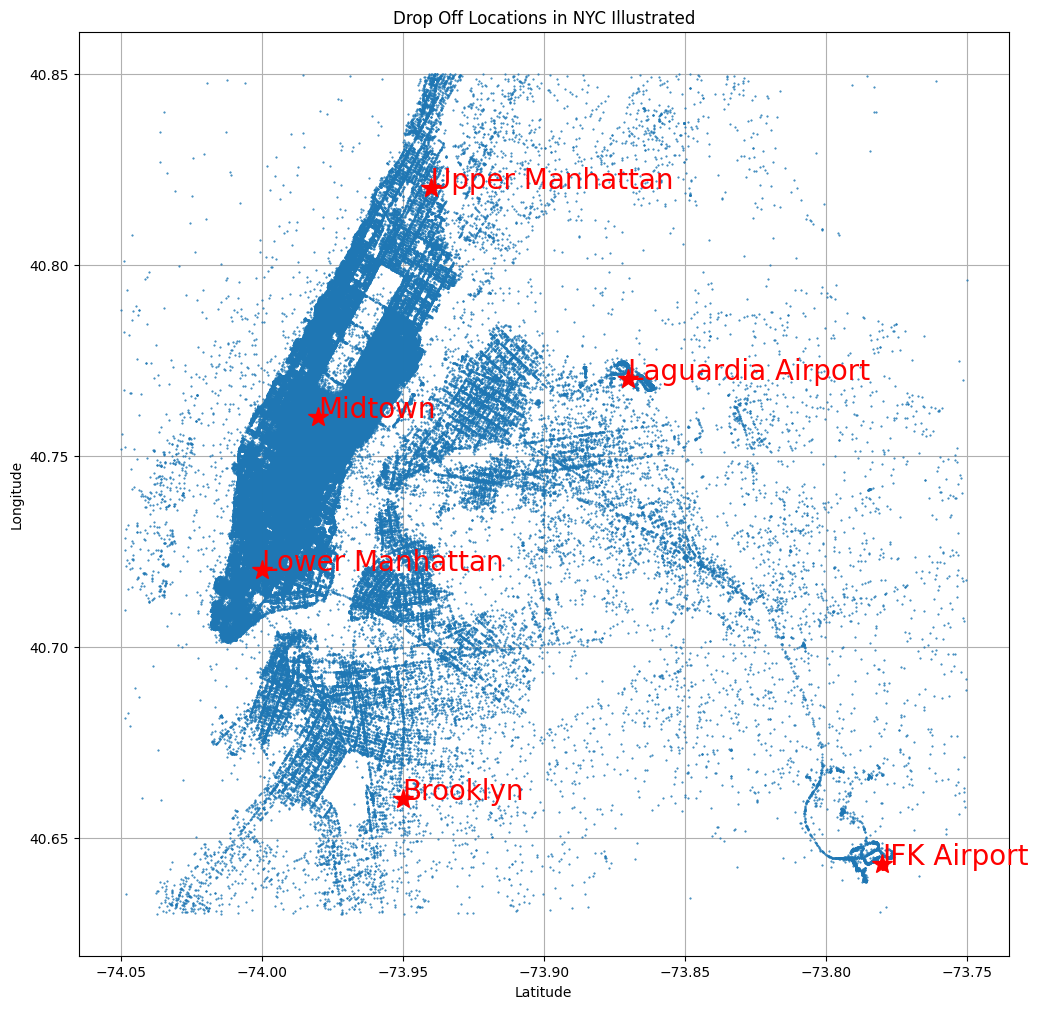

In [111]:
plot_lat_long(df2, landmarks, points='Drop Off')

In [112]:
df['year'] = df['pickup_datetime'].dt.year
df['month'] = df['pickup_datetime'].dt.month
df['day'] = df['pickup_datetime'].dt.day
df['day_of_week'] = df['pickup_datetime'].dt.dayofweek
df['hour'] = df['pickup_datetime'].dt.hour

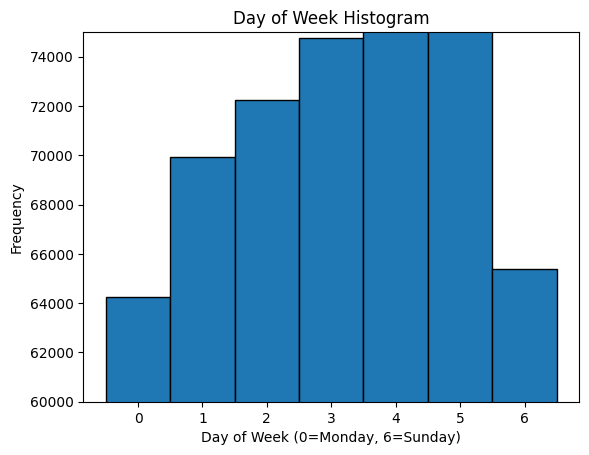

In [113]:
import numpy as np
df['day_of_week'].plot.hist(bins=np.arange(8)-0.5, ec='black',
ylim=(60000,75000))
plt.xlabel('Day of Week (0=Monday, 6=Sunday)')
plt.title('Day of Week Histogram')
plt.show()

In [114]:
print(df.isnull().sum())

key                  0
fare_amount          0
pickup_datetime      0
pickup_longitude     0
pickup_latitude      0
dropoff_longitude    5
dropoff_latitude     5
passenger_count      0
year                 0
month                0
day                  0
day_of_week          0
hour                 0
dtype: int64


In [115]:
df = df.dropna()

In [116]:
df.describe()

,fare_amount,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count,year,month,day,day_of_week,hour
count,499995.000000,499995.000000,499995.000000,499995.000000,499995.000000,499995.000000,499995.000000,499995.000000,499995.000000,499995.000000,499995.000000
mean,11.358182,-72.520091,39.920350,-72.522435,39.916526,1.683445,2011.739129,6.268617,15.684239,3.042020,13.510843
std,9.916069,11.856446,8.073318,11.797362,7.391002,1.307391,1.860897,3.437798,8.681092,1.949243,6.511596
min,-44.900000,-2986.242495,-3116.285383,-3383.296608,-2559.748913,0.000000,2009.000000,1.000000,1.000000,0.000000,0.000000
25%,6.000000,-73.992047,40.734916,-73.991382,40.734057,1.000000,2010.000000,3.000000,8.000000,1.000000,9.000000
50%,8.500000,-73.981785,40.752670,-73.980126,40.753152,1.000000,2012.000000,6.000000,16.000000,3.000000,14.000000
75%,12.500000,-73.967117,40.767076,-73.963572,40.768135,2.000000,2013.000000,9.000000,23.000000,5.000000,19.000000
max,500.000000,2140.601160,1703.092772,40.851027,404.616667,6.000000,2015.000000,12.000000,31.000000,6.000000,23.000000


<Axes: >

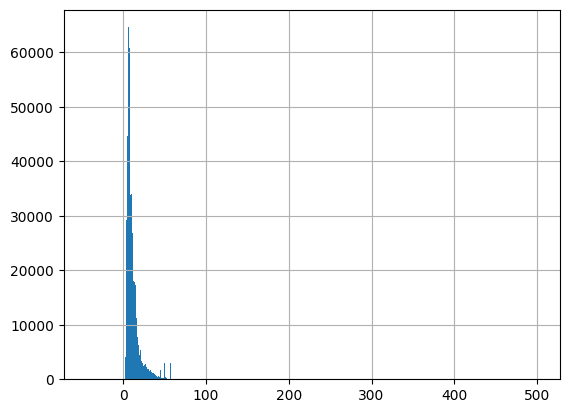

In [117]:
df['fare_amount'].hist(bins=500)

In [118]:
df = df[(df['fare_amount'] >=0) & (df['fare_amount'] <= 100)]

<Axes: >

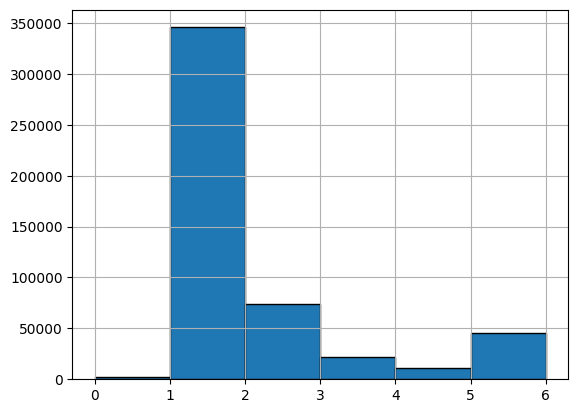

In [119]:
df['passenger_count'].hist(bins=6, ec='black')

In [120]:
df.loc[df['passenger_count'] == 0, 'passenger_count'] = 1

<Axes: xlabel='pickup_longitude', ylabel='pickup_latitude'>

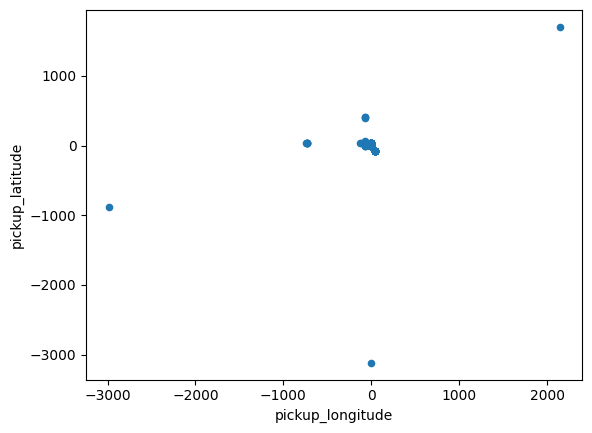

In [121]:
df.plot.scatter('pickup_longitude', 'pickup_latitude')

In [122]:
# range of longitude for NYC
nyc_min_longitude = -74.05
nyc_max_longitude = -73.75
# range of latitude for NYC
nyc_min_latitude = 40.63
nyc_max_latitude = 40.85
# only consider locations within NYC
for long in ['pickup_longitude', 'dropoff_longitude']:
    df = df[(df[long] > nyc_min_longitude) & (df[long] <
    nyc_max_longitude)]
for lat in ['pickup_latitude', 'dropoff_latitude']:
    df = df[(df[lat] > nyc_min_latitude) & (df[lat] <
    nyc_max_latitude)]

In [123]:
df = df.drop(['pickup_datetime'], axis=1)   

In [124]:
def euc_distance(lat1, long1, lat2, long2):
    return np.sqrt((lat1-lat2)**2 + (long1-long2)**2)

In [125]:
df['distance'] = euc_distance(df['pickup_latitude'],
                              df['pickup_longitude'], 
                              df['dropoff_latitude'],
                              df['dropoff_longitude'])

<Axes: xlabel='fare_amount', ylabel='distance'>

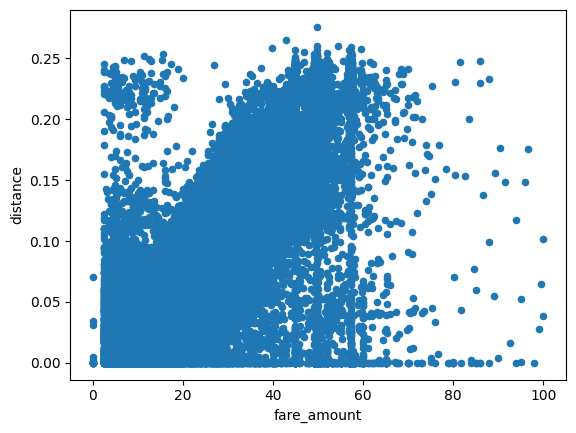

In [126]:
df.plot.scatter('fare_amount', 'distance')

In [127]:
airports = {'JFK_Airport': (-73.78,40.643),
'Laguardia_Airport': (-73.87, 40.77),
'Newark_Airport' : (-74.18, 40.69)}

In [128]:
for airport in airports:
    df['pickup_dist_' + airport] = euc_distance(df['pickup_latitude'],
                                    df['pickup_longitude'],
                                    airports[airport][1],
                                    airports[airport][0])
    df['dropoff_dist_' + airport] = euc_distance(df['dropoff_latitude'],
                                    df['dropoff_longitude'],
                                    airports[airport][1],
                                    airports[airport][0])

In [129]:
df

,key,fare_amount,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count,year,month,day,day_of_week,hour,distance,pickup_dist_JFK_Airport,dropoff_dist_JFK_Airport,pickup_dist_Laguardia_Airport,dropoff_dist_Laguardia_Airport,pickup_dist_Newark_Airport,dropoff_dist_Newark_Airport
0,2009-06-15 17:26:21.0000001,4.5,-73.844311,40.721319,-73.841610,40.712278,1,2009,6,15,0,17,0.009436,0.101340,0.092710,0.055043,0.064326,0.337147,0.339123
1,2010-01-05 16:52:16.0000002,16.9,-74.016048,40.711303,-73.979268,40.782004,1,2010,1,5,1,16,0.079696,0.245731,0.242961,0.157402,0.109925,0.165330,0.220812
2,2011-08-18 00:35:00.00000049,5.7,-73.982738,40.761270,-73.991242,40.750562,2,2011,8,18,3,0,0.013674,0.234714,0.237050,0.113076,0.122790,0.209742,0.198236
3,2012-04-21 04:30:42.0000001,7.7,-73.987130,40.733143,-73.991567,40.758092,1,2012,4,21,5,4,0.025340,0.225895,0.240846,0.122792,0.122149,0.197636,0.200358
4,2010-03-09 07:51:00.000000135,5.3,-73.968095,40.768008,-73.956655,40.783762,1,2010,3,9,1,7,0.019470,0.225847,0.225878,0.098115,0.087741,0.225807,0.242228
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
499995,2015-05-07 18:45:12.0000004,7.0,-73.978775,40.766724,-73.966072,40.758537,1,2015,5,7,3,18,0.015112,0.234135,0.219024,0.108824,0.096753,0.215356,0.224639
499996,2010-09-13 12:11:34.0000004,13.7,-74.002932,40.718408,-74.009442,40.710952,1,2010,9,13,0,12,0.009898,0.235340,0.239293,0.142593,0.151429,0.179332,0.171840
499997,2014-08-25 00:22:20.0000001,25.0,-73.983885,40.725611,-73.896482,40.700980,1,2014,8,25,0,0,0.090807,0.219986,0.130114,0.122230,0.073926,0.199322,0.283731
499998,2015-01-12 12:17:32.0000001,6.5,-73.974617,40.756512,-73.970184,40.764801,6,2015,1,12,0,12,0.009400,0.225301,0.225844,0.105483,0.100319,0.215884,0.222751


In [130]:
df = df.drop(['key'], axis=1)

In [131]:
df_prescaled = df.copy()    

In [132]:
df_scaled = df.drop(['fare_amount'], axis=1)

In [133]:
from sklearn.preprocessing import scale
df_scaled = scale(df_scaled)

In [134]:
cols = df.columns.tolist()
cols.remove('fare_amount')  

In [135]:
df_scaled = pd.DataFrame(df_scaled, columns=cols, index=df.index)

In [136]:
df_scaled = pd.concat([df_scaled, df['fare_amount']], axis=1)
df = df_scaled.copy()

In [137]:
X = df.drop('fare_amount', axis=1)
y = df['fare_amount']

In [138]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=67)

In [139]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

In [140]:
model = Sequential()
model.add(Dense(128, activation='relu', input_dim=X_train.shape[1]))
model.add(Dense(64, activation='relu'))
model.add(Dense(32, activation='relu'))
model.add(Dense(8, activation='relu'))
model.add(Dense(1))
model.summary()

Model: "sequential_6"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense_30 (Dense)            (None, 128)               2304      
                                                                 
 dense_31 (Dense)            (None, 64)                8256      
                                                                 
 dense_32 (Dense)            (None, 32)                2080      
                                                                 
 dense_33 (Dense)            (None, 8)                 264       
                                                                 
 dense_34 (Dense)            (None, 1)                 9         
                                                                 
Total params: 12913 (50.44 KB)
Trainable params: 12913 (50.44 KB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


In [141]:
model.compile(loss='mse', optimizer='adam', metrics=['mse'])
model.fit(X_train, y_train, epochs=5, batch_size=128)

Epoch 1/5


  15/3022 [..............................] - ETA: 11s - loss: 180.0761 - mse: 180.0761  

2025-02-12 14:59:39.901001: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.


3022/3022 [==============================] - 11s 3ms/step - loss: 115.0349 - mse: 115.0349
Epoch 2/5
3022/3022 [==============================] - 10s 3ms/step - loss: 654.8347 - mse: 654.8347
Epoch 3/5
3022/3022 [==============================] - 10s 3ms/step - loss: 2191.3420 - mse: 2191.3420
Epoch 4/5
3022/3022 [==============================] - 10s 3ms/step - loss: 1707.6184 - mse: 1707.6184
Epoch 5/5
3022/3022 [==============================] - 10s 3ms/step - loss: 978.3432 - mse: 978.3432


In [142]:
def predict_random(df_prescaled, X_test, model):
    sample = X_test.sample(n=1, random_state=np.random.randint(low=0, high=10000))
    idx = sample.index[0]
    actual_fare = df_prescaled.loc[idx, 'fare_amount']
    day_names = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
    day_of_week = day_names[df_prescaled.loc[idx, 'day_of_week']]
    hour = df_prescaled.loc[idx, 'hour']
    predicted_fare = model.predict(sample)[0][0]
    rmse = np.sqrt((predicted_fare-actual_fare)**2)
    print("Trip Details: {}, {}:00hrs".format(day_of_week, hour))
    print("Actual Fare: ${:.2f}".format(actual_fare))
    print("Predicted Fare: ${:.2f}".format(predicted_fare))
    print("RMSE: ${:.2f}".format(rmse))

In [145]:
predict_random(df_prescaled, X_test, model)

1/1 [==============================] - 0s 10ms/step
Trip Details: Wednesday, 9:00hrs
Actual Fare: $5.50
Predicted Fare: $5.34
RMSE: $0.16
